# Phase 7A Level 3：硬斜率约束 pure DNN 验证

**问题**：在 Level 2 三状态模型已通过的基础上，只增加上一时刻电流和
\(|I_k-I_{k-1}|\le2\,\mathrm{A}\) 硬约束，pure DNN 是否仍能严格通过？

本实验不增加温度、DFN、扰动、压力场、教师数据规模或网络复杂度。

## 1. 状态与唯一新增约束

\[
x_k=\begin{bmatrix}SOC_k&V_{1,k}&V_{2,k}&I_{k-1}\end{bmatrix}^{\mathsf T},
\qquad |I_k-I_{k-1}|\le2\ \mathrm{A}.
\]

其余 2RC 动力学、电流边界 \(0\le I_k\le10\,\mathrm{A}\) 和端电压上限
\(V_{\mathrm{tr},k}\le4.20\,\mathrm{V}\) 与 Level 2 保持一致。

## 2. 读取冻结结果

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd(); OUT=ROOT/'outputs'/'phase7a_level3_slew'; DATA=ROOT/'data'/'phase7a_level3_slew'
metrics=json.loads((OUT/'metrics.json').read_text(encoding='utf-8'))
offline=pd.read_csv(OUT/'dnn_offline_metrics.csv')
closed=pd.read_csv(DATA/'closed_loop_metrics.csv')
audit=pd.read_csv(DATA/'multistart_state_summary.csv')
print(metrics['study_name'], metrics['status'])

phase7a_level3_2rc_slew_pure_dnn completed


## 3. 教师覆盖与双冻结测试哈希

In [2]:
display(pd.DataFrame([metrics['teacher']]))
display(pd.DataFrame(metrics['frozen_test_hashes']).T)
assert metrics['teacher']['success']
assert metrics['teacher']['attempted_trajectories']==400
assert metrics['teacher']['low_current_label_count']>=100
assert metrics['teacher']['checks']['hard_slew_constraint']

,attempted_trajectories,accepted_trajectories,acceptance_fraction,sample_count,low_current_label_count,checks,success
0,400,400,1.0,5760,183,"{'acceptance': True, 'complete_accepted_trajec...",True


,path,sha256,trajectory_count,sample_count
test,global_frozen_test.csv,484b71df5f3afe8dfcf33f4202a608f69d7292c1411621...,36,288
terminal_test,terminal_frozen_test.csv,7ba4a2359016a3549997bc3f892a492ed55f77e872fe3d...,20,480


## 4. 100×15 多起点教师审计

,state_count,warm_starts_per_state,near_optimal_multivalued_fraction,near_optimal_first_action_range_p95_a,maximum_near_optimal_first_action_range_a,checks,success
0,100,15,0.0,0.016088,0.022572,"{'exact_audit_contract': True, 'all_optimizer_...",True


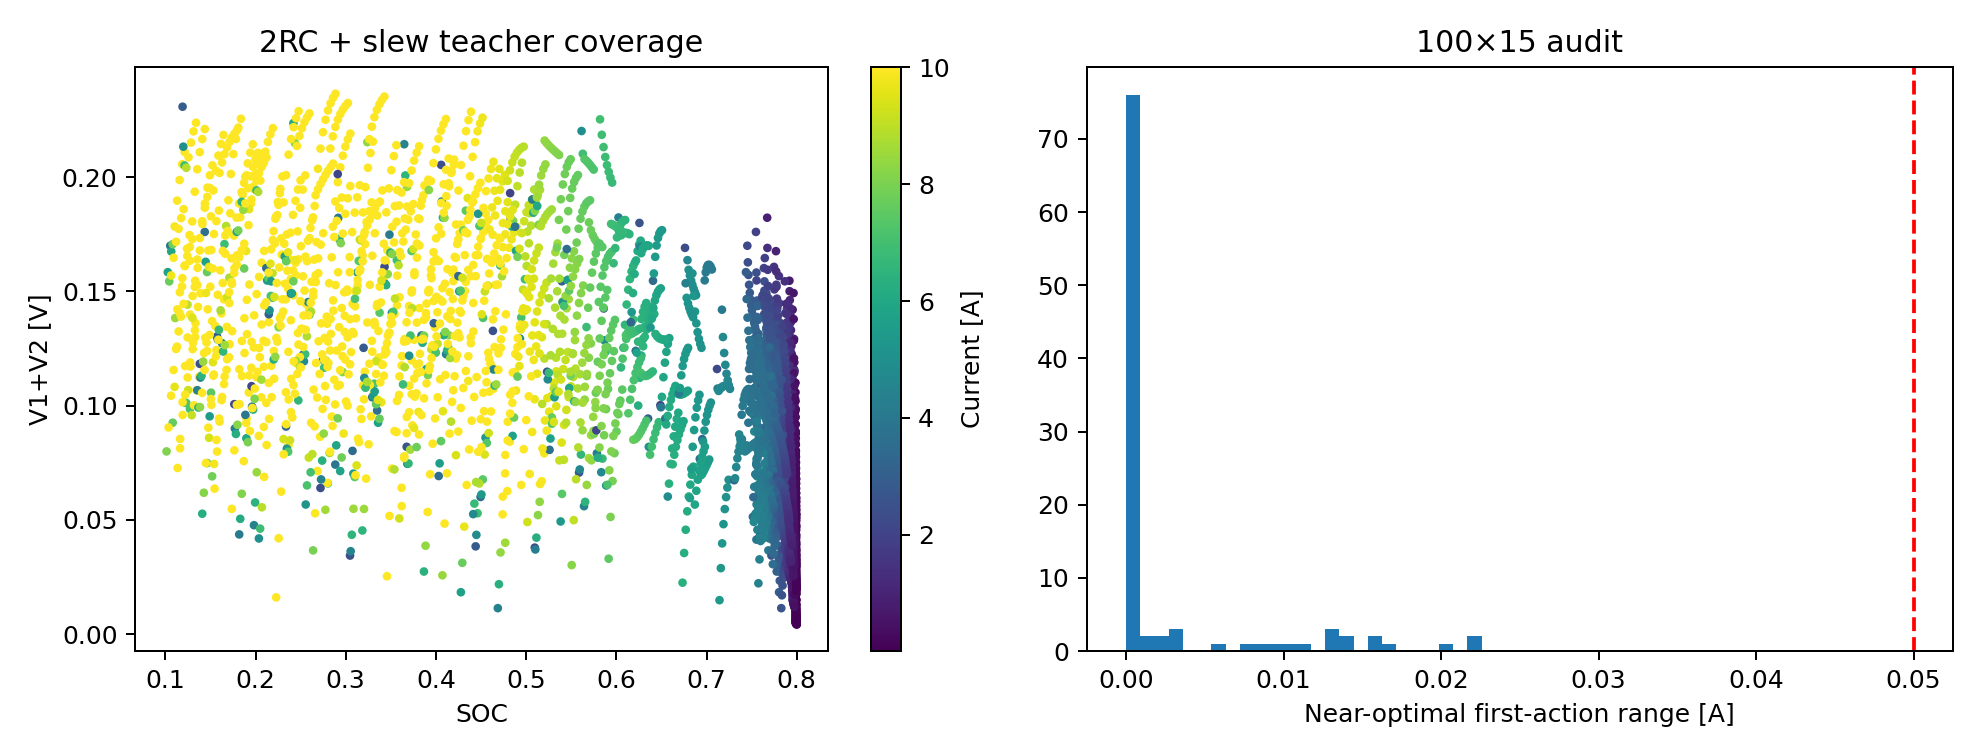

In [3]:
display(pd.DataFrame([metrics['teacher_audit']]))
assert len(audit)==100
assert metrics['teacher_audit']['success']
assert metrics['teacher_audit']['near_optimal_multivalued_fraction']==0
display(Image(filename=str(OUT/'figures'/'teacher_and_audit.png')))

## 5. 深层 LBFGS 五种子离线结果

In [4]:
view=offline[['seed','test_nrmse','terminal_test_nrmse','test_bias_a','terminal_test_bias_a']].copy()
view['global_test_nrmse_percent']=100*view.pop('test_nrmse')
view['terminal_test_nrmse_percent']=100*view.pop('terminal_test_nrmse')
display(view)
assert (view.global_test_nrmse_percent<1).all()
assert (view.terminal_test_nrmse_percent<1).all()

,seed,test_bias_a,terminal_test_bias_a,global_test_nrmse_percent,terminal_test_nrmse_percent
0,22,-0.000714,0.003296,0.493329,0.507365
1,42,-0.007123,-0.000187,0.343147,0.442341
2,73,-0.002253,0.003424,0.350413,0.355677
3,101,-0.000402,0.004121,0.331267,0.404029
4,137,-0.000640,0.001673,0.520665,0.328973


## 6. 同模型闭环与硬斜率门槛

,seed,target_reach_fraction,maximum_voltage_violation_v,maximum_slew_violation_a,maximum_current_step_a,speedup,current_nrmse_percent,charge_time_gap_percent
0,22,1.0,0.0,0.128929,2.128929,1268.914364,0.340477,0.869039
1,42,1.0,0.0,0.106647,2.106647,1057.910722,0.300816,0.603758
2,73,1.0,0.0,0.113486,2.113486,1035.211927,0.236538,0.460725
3,101,1.0,0.0,0.087773,2.087773,1069.127063,0.228089,0.778417
4,137,1.0,0.0,0.068673,2.068673,1516.970840,0.292025,0.603758


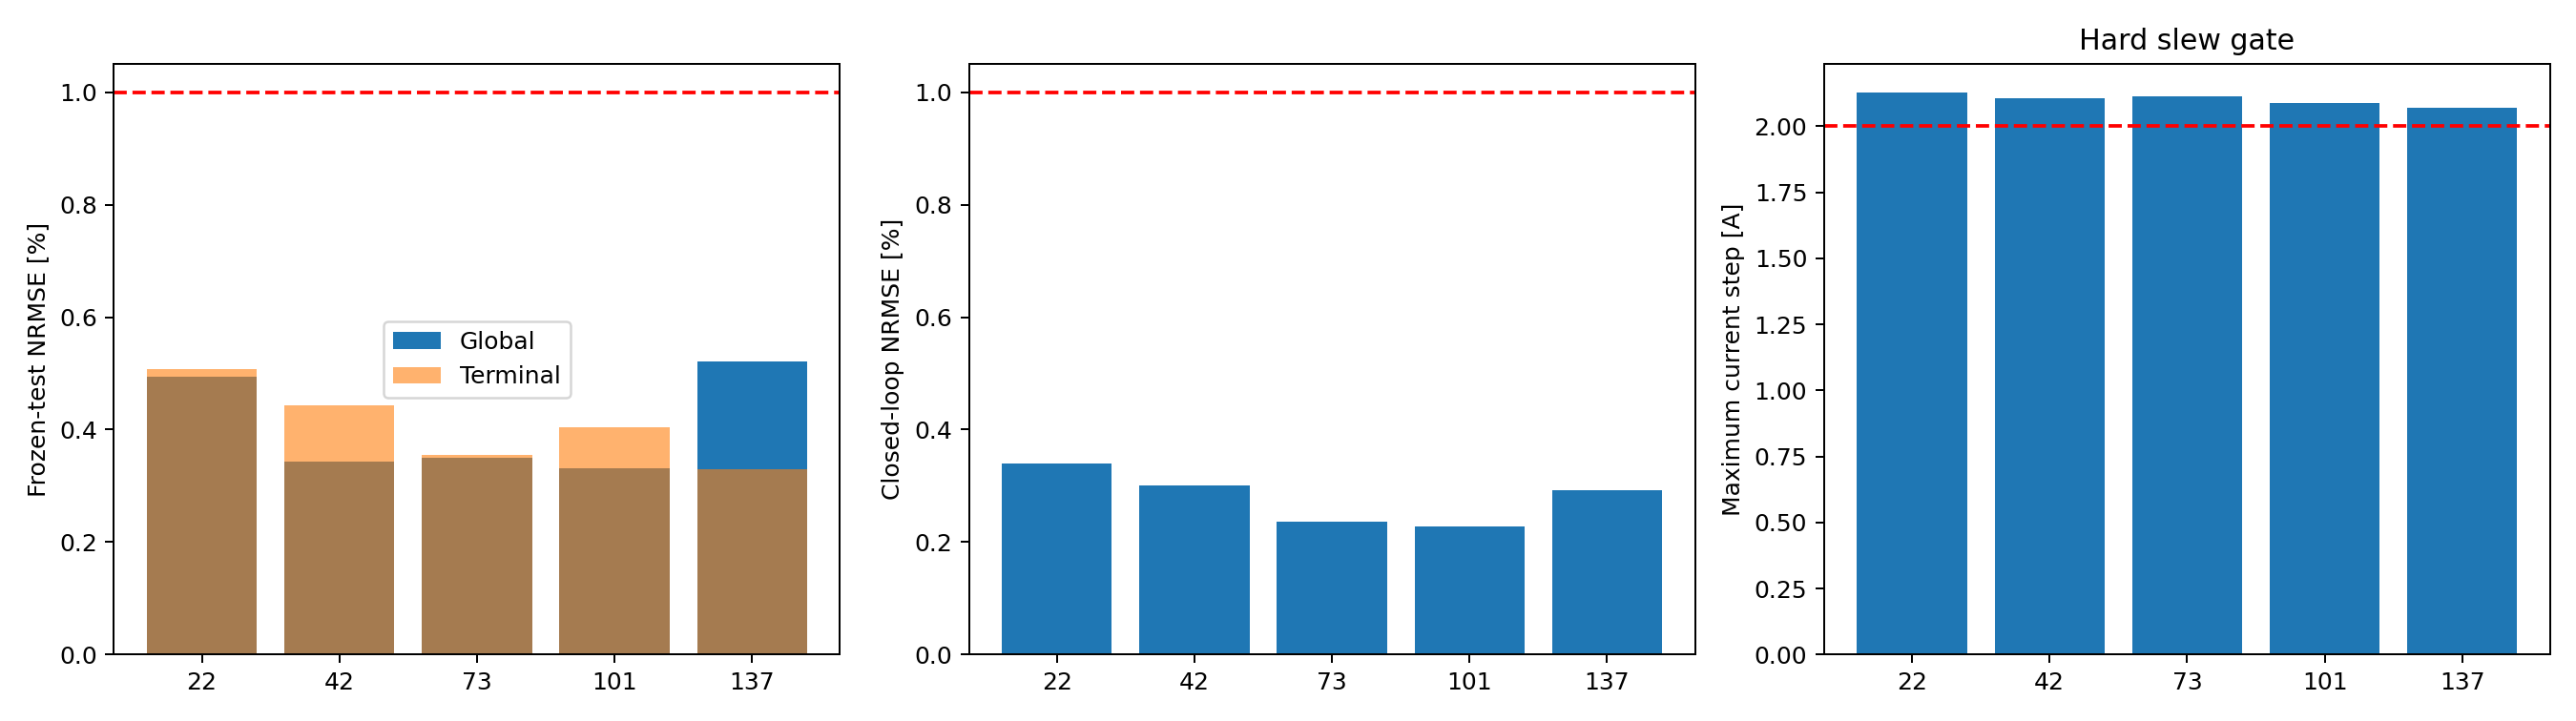

In [5]:
cols=['seed','mean_current_nrmse','mean_charge_time_gap_fraction','target_reach_fraction',
      'maximum_voltage_violation_v','maximum_slew_violation_a','maximum_current_step_a','speedup']
view=closed[cols].copy()
view['current_nrmse_percent']=100*view.pop('mean_current_nrmse')
view['charge_time_gap_percent']=100*view.pop('mean_charge_time_gap_fraction')
display(view)
display(Image(filename=str(OUT/'figures'/'five_seed_validation.png')))
assert (view.current_nrmse_percent<1).all()
assert (view.charge_time_gap_percent<2).all()
assert (view.target_reach_fraction==1).all()
assert (view.maximum_voltage_violation_v==0).all()
assert (view.speedup>100).all()
assert (view.maximum_slew_violation_a>0.001).all()

## 7. 阶段判定

In [6]:
display(pd.DataFrame([metrics['decision']['checks']]))
display(pd.DataFrame([metrics['closed_loop']['checks']]))
print(metrics['decision']['conclusion'])
assert metrics['decision']['level3_success'] is False
assert metrics['decision']['proceed_to_level4'] is False
assert metrics['closed_loop']['checks']['zero_slew_violation'] is False

,teacher_determinism_passed,dual_offline_tests_passed,same_model_closed_loop_passed
0,True,True,False


,all_seed_current_nrmse,all_seed_charge_time_gap,all_seed_target_reach,zero_voltage_violation,zero_current_violation,zero_slew_violation,all_seed_speedup
0,True,True,True,True,True,False,True


Level 3 硬斜率约束首次导致 pure DNN 闭环失败


## 结论

Level 3 的教师确定性、双冻结离线拟合、闭环电流误差、终端到达、安全电压和
计算速度均通过；唯一失败项是 pure DNN 无法严格保证新增的硬斜率约束。

因此硬斜率约束是本消融序列中首次确认的 pure DNN 严格失效因素。依据预注册
停止规则，不进入 Level 4。后续若继续研究，应单独立项比较安全投影、分区 DNN
或 ANN 辅助 MPC，而不能把这些方法记为原始 pure DNN。